In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

column_names = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv('wdbc.data', header=None, names=column_names)

df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print('Dataset shape:', df.shape)

Dataset shape: (569, 31)


In [17]:
missing_values = df.isnull().sum().sum()
print(f'Total Missing Values: {missing_values}')

duplicates = df.duplicated().sum()
print(f'Duplicate Rows Count: {duplicates}')

print(df.info())

print(df.shape)

print('\nDataset Summary (describe):')
display(df.describe().T)

Total Missing Values: 0
Duplicate Rows Count: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


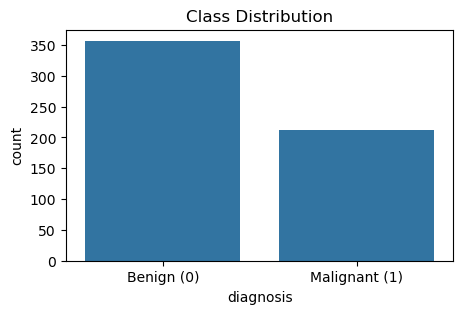

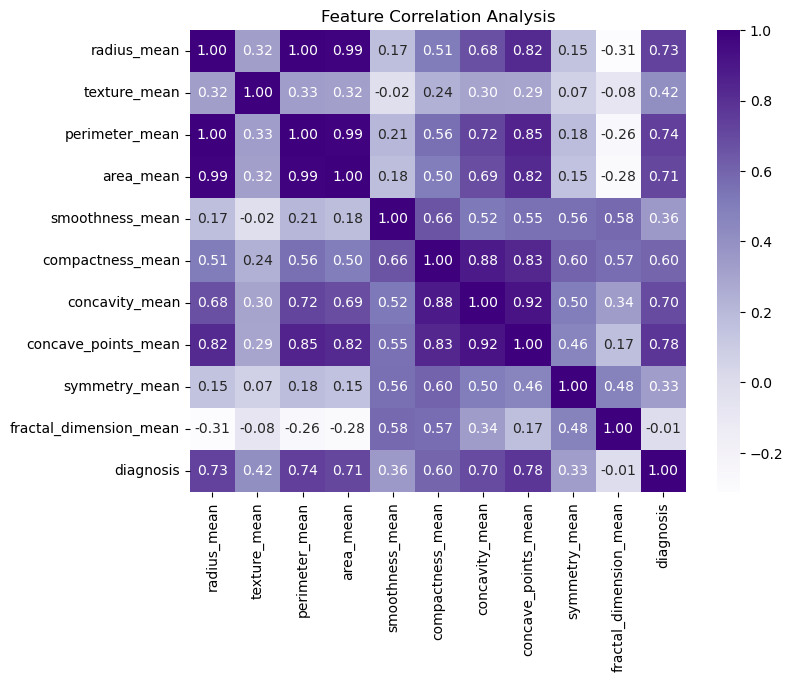

In [24]:
plt.figure(figsize=(5, 3))
sns.countplot(x='diagnosis', data=df)
plt.xticks([0, 1], ['Benign (0)', 'Malignant (1)'])
plt.title('Class Distribution')
plt.show()

mean_cols = [c for c in df.columns if 'mean' in c] + ['diagnosis']
plt.figure(figsize=(8, 6))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f', cmap='Purples')
plt.title('Feature Correlation Analysis')
plt.show()

In [19]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train size: 455 | Test size: 114


In [20]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring=['accuracy', 'f1'],
    refit='accuracy',
)
dt_grid.fit(X_train, y_train)

dt_results = pd.DataFrame(dt_grid.cv_results_)
table_1 = dt_results[[
    'param_criterion',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_accuracy',
    'mean_test_f1',
]].copy()
table_1['mean_test_accuracy'] *= 100
table_1['mean_test_f1'] *= 100
table_1.columns = [
    'Criterion',
    'Max Depth',
    'Min Samples Split',
    'Min Samples Leaf',
    'Avg CV Accuracy (%)',
    'Avg CV F1 Score (%)',
]

print(
    table_1.sort_values(by='Avg CV Accuracy (%)', ascending=False)
    .head(5)
    .to_string(index=False)
)
best_dt = dt_grid.best_estimator_

Table 1: Decision Tree Hyperparameter Evaluation (Top 5)
Criterion Max Depth  Min Samples Split  Min Samples Leaf  Avg CV Accuracy (%)  Avg CV F1 Score (%)
  entropy      None                  5                 2            94.725275            92.972371
  entropy        10                  5                 2            94.725275            92.972371
  entropy         7                  5                 2            94.725275            92.972371
  entropy         7                  5                 1            94.505495            92.735217
  entropy        10                  5                 1            94.505495            92.735217


In [21]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring=['accuracy', 'f1'],
    refit='accuracy',
)
rf_grid.fit(X_train, y_train)

rf_results = pd.DataFrame(rf_grid.cv_results_)
table_2 = rf_results[[
    'param_n_estimators',
    'param_max_depth',
    'param_max_features',
    'mean_test_accuracy',
    'mean_test_f1',
]].copy()
table_2['mean_test_accuracy'] *= 100
table_2['mean_test_f1'] *= 100
table_2.columns = [
    'n_estimators',
    'Max Depth',
    'Max Features',
    'Avg CV Accuracy (%)',
    'Avg CV F1 Score (%)',
]

print(
    table_2.sort_values(by='Avg CV Accuracy (%)', ascending=False)
    .head(5)
    .to_string(index=False)
)
best_rf = rf_grid.best_estimator_

Table 2: Random Forest Hyperparameter Evaluation (Top 5)
 n_estimators Max Depth Max Features  Avg CV Accuracy (%)  Avg CV F1 Score (%)
           50      None         sqrt            96.703297            95.612972
           50        10         sqrt            96.703297            95.612972
          100        10         sqrt            96.263736            95.009361
          100      None         sqrt            96.263736            95.009361
           50      None         log2            96.043956            94.602731


In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_fold_accs = []
rf_fold_accs = []

for train_idx, val_idx in skf.split(X_train, y_train):
  X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
  y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

  model_dt = best_dt.fit(X_tr, y_tr)
  dt_fold_accs.append(model_dt.score(X_val, y_val) * 100)

  model_rf = best_rf.fit(X_tr, y_tr)
  rf_fold_accs.append(model_rf.score(X_val, y_val) * 100)

best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

table_3 = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Fold 1': [dt_fold_accs[0], rf_fold_accs[0]],
    'Fold 2': [dt_fold_accs[1], rf_fold_accs[1]],
    'Fold 3': [dt_fold_accs[2], rf_fold_accs[2]],
    'Fold 4': [dt_fold_accs[3], rf_fold_accs[3]],
    'Fold 5': [dt_fold_accs[4], rf_fold_accs[4]],
    'Average': [np.mean(dt_fold_accs), np.mean(rf_fold_accs)],
})

print(df.info())

print(df.shape)
print(df.info())

print(df.shape)
print(table_3.to_string(index=False))

Table 3: 5-Fold Cross-Validation Accuracy Comparison
        Model    Fold 1    Fold 2    Fold 3    Fold 4    Fold 5   Average
Decision Tree 90.109890 96.703297 92.307692 91.208791 94.505495 92.967033
Random Forest 95.604396 98.901099 93.406593 94.505495 97.802198 96.043956


Test Evaluation Metrics:
   Metric  Decision Tree  Random Forest
 Accuracy       0.956140       0.973684
Precision       1.000000       1.000000
   Recall       0.880952       0.928571
 F1-Score       0.936709       0.962963


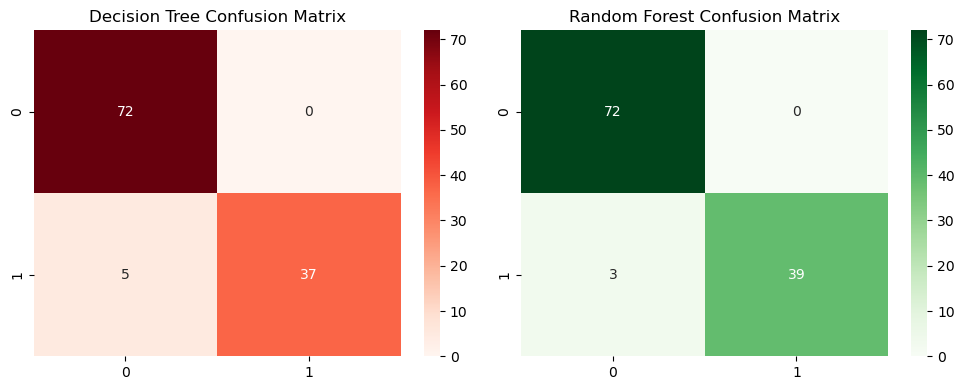

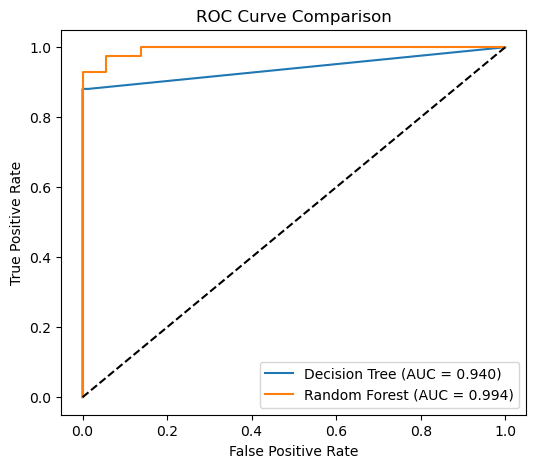

In [27]:
dt_preds = best_dt.predict(X_test)
rf_preds = best_rf.predict(X_test)

dt_probs = best_dt.predict_proba(X_test)[:, 1]
rf_probs = best_rf.predict_proba(X_test)[:, 1]

eval_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [
        best_dt.score(X_test, y_test),
        precision_score(y_test, dt_preds),
        recall_score(y_test, dt_preds),
        f1_score(y_test, dt_preds),
    ],
    'Random Forest': [
        best_rf.score(X_test, y_test),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds),
    ],
})

print('Test Evaluation Metrics:')
print(eval_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(
    confusion_matrix(y_test, dt_preds),
    annot=True,
    fmt='d',
    ax=axes[0],
    cmap='Reds',
)
axes[0].set_title('Decision Tree Confusion Matrix')
sns.heatmap(
    confusion_matrix(y_test, rf_preds),
    annot=True,
    fmt='d',
    ax=axes[1],
    cmap='Greens',
)
axes[1].set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.3f})'
)
plt.plot(
    fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})'
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()